In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Utils method

For definition of crossovers we suggest to use the following functions based on hybperbolic tangent.
$$
\log(F(s))\equiv\log(S^H)\\
\log(F(s))=H\log(S)\\
H=\frac{\log(F(s))}{\log(S)}\\
\text{If the Hurst exponent changes across scales, we can compute its local value as the slope of }  \log(F(s)) \text{with respect to } \log(S)\\
H=\frac{\partial \log(F(s))}{\partial s}\\
\text{R is transition width that quantifies the smoothness of the Hurst changing part}\\
\text{The hyperbolic tangent is a smooth activation function that naturally arises in the modeling of fluctuation functions with crossovers.
Its key property is that it provides a differentiable, sigmoidal transition between two asymptotic states—making
it ideal for representing the local Hurst exponent as a continuous function of scale}\\
\text{if s<C}=H_1\\
\text{is s>C}=H_2\\
\text{in}\tanh \text{on}(-\infty)\text{function is -1}\\
\text{in}\tanh \text{on}(\infty)\text{function is 1}\\
\text{The function shows a linear transition behavior:} y=kx+b\\
y=k\tanh(x)+b\\
H(s)=k\tanh(x)+b\\
\text{if s<C}=\tanh=-1=y=-k+b=H_1\\
\text{is s>C}=\tanh=1=y=k+b=H_2\\
\begin{cases}
H_1=b-k\\
H_2=k+b
\end{cases}\\
\begin{cases}
b=\frac{H_1+H_2}{2}\\
K=\frac{H_2-H_1}{2}
\end{cases}\\
x=\frac{\log(s)-\log(c)}{R}\\
H(s)=\frac{H_2-H_1}{2}\tanh(\frac{\log(s)-\log(c)}{R})+\frac{H_1+H_2}{2}\\
H_s=\frac{\partial \log(F(s))}{\partial s}\\
\log(F(s))=\int H_s\,d\log(S)+C\\
\log(F(s))=\int \frac{H_2-H_1}{2} \tanh(\frac{\log(s)-\log(c)}{R})+\frac{H_1+H_2}{2}\,d\log(s)+C\\
\log(F(s))=\frac{H_1+H_2}{2} \log(s)+\frac{H_2-H_1}{2}\int \tanh \frac{\log(s)-\log(c)}{R}\,d\log(s)+C\\
\log(s)-\log(c)=d\log(s)\\
x=\frac{\log(s)-\log(c)}{R}=s\\
dx=\frac{d(\log(s)-\log(c))}{R}\\
d(\log(s)-\log(c))=dx*R\\
\int \tanh \frac{\log(s)-\log(c)}{R}\,d\log(s)=\int \tanh \frac{\log(s)-\log(c)}{R}\,Rd(\frac{\log(s)-\log(c)}{R})\\
R*\int\tanh(s)\,ds=R*\ln(\cosh(\frac{\log(s)-\log(c)}{R}))+C\\
F(s)=\frac{H_1+H_2}{2}\log(s)+\frac{H_2-H_1}{2}*R\ln(\cosh(\frac{s-c}{R}))+C\\
if s\rightarrow\infty:\\
\cosh(s)=\frac{e^s+e^-s}{2}=\frac{e^s}{2}\\
\ln\cosh(s)=\ln(\frac{e^s}{2})=s-\ln(2)\\
if s\rightarrow-\infty:\\
\cosh(s)=\frac{e^s+e^-s}{2}=\frac{e^-s}{2}\\
\ln\cosh(s)=\ln(\frac{e^-s}{2})=-s-\ln(2)\\
\text{Let's check theese conclusions for correctness:}\\
\text{if s<c and s on small scales}:\\
\log(F(s))=\frac{H_1+H_2}{2}\log(s)+\frac{H_2-H_1}{2}*R\ln(\cosh(\frac{\frac{s}{c}}{R}))+C\\
\frac{s}{c}<1\rightarrow\ln(\frac{s}{c})<0\rightarrow s\rightarrow-\infty\\
\ln(\cosh(\frac{\frac{s}{c}}{R}))=-\ln(\frac{\frac{s}{c}}{R})-\ln(2)\\
\log(F(s))=\frac{H_1+H_2}{2}\ln(s)-\frac{H_2-H_1}{2}\ln(\frac{s}{c})-\frac{H_2-H_1}{2}R\ln(2)+C\\
\ln(\frac{s}{c})=\ln(s)-\ln(c)\\
\ln(s)(\frac{H_1+H_2}{2}-\frac{H_2+H_1}{2})=H_1\ln(s)\\
\log(F(s))=H_1*\ln(s)+C\\
F(s)\equiv s^H1\\
\text{conclusion is correct}\\
\text{if s>c and s on large scales}:\\
\frac{s}{c}>1\rightarrow\ln(\frac{s}{c})>0\rightarrow s\rightarrow\infty\\
\ln(\cosh(\frac{\frac{s}{c}}{R}))=\ln(\frac{\frac{s}{c}}{R})-\ln(2)\\
\log(F(s))=\frac{H_1+H_2}{2}\ln(s)+\frac{H_2-H_1}{2}R(\frac{\ln(\frac{s}{c})}{R}-\ln(2))+C\\
\ln(s)*(\frac{H_1+H_2}{2}+\frac{H_2-H_1}{2})=H_2\ln(s)\\
\log(F(s))=H_2*\ln(s)+C\\
F(s)\equiv s^H2\\
\text{conclusion is correct}\\
$$

# Boundary functions

To make the function behave correctly at the edges of the domain, we use two functions:

$$
\text{tf minus inf:}\\
if c_1\rightarrow-\infty:\\
if x-c_2<0\rightarrow\frac{x-c_2}{R}\rightarrow-\infty:\\
\ln(\cosh(y))=-y-\ln(2)=-(\frac{x-c_2}{R})-\ln(2)\\
F(s)=x-R(-(\frac{x-c_2}{R})-\ln(2))+R\ln(2)\\
F(s)=2x-c_2+2R\ln(2)\text{is a linear decreasing function}\\
if x-c_2>0\rightarrow\frac{x-c_2}{R}\rightarrow\infty:\\
\ln(\cosh(y))=y-\ln(2)=-(\frac{x-c_2}{R})-\ln(2)\\
F(s)=c_2+2R\ln(2)\text{is a constant(saturation)}
\text{tf plus inf:}\\
if c_2\rightarrow\infty:\\
if x-c_1<0\rightarrow\frac{x-c_1}{R}\rightarrow-\infty:\\
\ln(\cosh(y))=-y-\ln(2)=-(\frac{x-c_1}{R})-\ln(2)\\
F(s)=-x+c_1+2R\ln(2)\text{is a linear decreasing function}\\
if x-c_1>0\rightarrow\frac{x-c_1}{R}\rightarrow\infty:\\
\ln(\cosh(y))=y-\ln(2)=-(\frac{x-c_1}{R})-\ln(2)\\
F(s)=x-c_1-2R\ln(2)\text{is a linear increasing function}\\
$$

# Base approximation function

$$
\text{cross fcn sloped}\\
F(s)=R_1\ln(\cosh(\frac{x-c_1}{R}))-R_1-\ln(2)-R_2\ln(\cosh(\frac{x-c_2}{R}))-R_2\ln(2)\\
if x<C_1 \text{left part:}\rightarrow x-C_1\rightarrow-\infty\\
F(s)=-x+C_1\rightarrow\text{function is decreasing}\\
if x>C_1 \text{left part:}\rightarrow x-C_1\rightarrow\infty\\
F(s)=x-C_1\rightarrow\text{function is increasing}\\
if x<C_2 \text{right part:}\rightarrow x-C_2\rightarrow-\infty\\
F(s)=-x+C_2\rightarrow\text{function is decreasing}\\
if x>C_2 \text{right part:}\rightarrow x-C_2\rightarrow\infty\\
F(s)=x-C_2\rightarrow\text{function is increasing}\\
if x<C_1 \rightarrow\text{function is constant}\\
if C_1<x<C_2\rightarrow\text{linear function is increasing}\\
if x>C_2 \rightarrow\text{linear function is constant}\\
$$

In [2]:
def tf_minus_inf(x:np.ndarray, c2:float, r2:float):
    dx=(x-c2)/r2
    return x-r2*np.log(np.cosh(dx))+r2*np.log(2)

def tf_plus_inf(x:np.ndarray, c1:float, r1:float):
    dx=(x-c1)/r1
    return r1*np.log(np.cosh(dx))-r1*np.log(2)

def ff_base_appriximation(x:np.ndarray,r1:float, r2:float, c1:float, c2:float)->np.ndarray:
    if np.isinf(c1):
        return tf_minus_inf(x,c2,r2)
    if np.isinf(c2):
        return tf_plus_inf(x,c1,r1)
    dx_1=(x-c1)/r1
    dx_2=(x-c2)/r2

    left_peace=r1*np.log(np.cosh(dx_1))-r1*np.log(2)
    right_pease=r2*np.log(np.cosh(dx_2))-r2*np.log(2)

    return left_peace-right_pease

In [3]:
def get_number_parameter_by_number_crossovers(n: int) -> tuple[int, int]:
    """Returns the number of slopes and rigidity parameters for a given number of crossovers.

    Args:
        n (int): The number of crossovers in the fluctuation function.

    Returns:
        tuple[int, int]: A tuple containing the amount of slopes and the amount of rigidity (R) parameters.
    """
    slopes = n + 1
    R = n
    return slopes, R

In [4]:
def cross_fcn_sloped(x, y_0, *args, crossover_amount: int):
    """Computes the sloped crossover function for fluctuation characteristic approximation.

    This function serves as the base element for approximating fluctuation characteristics
    with multiple Hurst coefficients, incorporating crossover points.

    Args:
        x (np.ndarray): Points where the fluctuation function F(s) is calculated.
        y_0 (float): Y-intercept of the function.
        *args: Variable length argument list containing crossover values, slopes, and rigidity parameters.
        crossover_amount (int): Number of crossover points where the Hurst coefficient changes.

    Returns:
        np.ndarray: The computed function values at the given points.
    """
    crossovers = crossover_amount
    slopes_num, _ = get_number_parameter_by_number_crossovers(crossover_amount)
    C = args[:crossovers]
    slope = args[crossovers : crossovers + slopes_num]
    R = args[crossovers + slopes_num :]

    slope_fcn = np.zeros_like(x, dtype=float)
    fcn_bias = 0

    for index in range(slopes_num):
        if index == 0:
            left_c = -np.inf
            left_r = 1

        else:
            left_c = C[index - 1]
            left_r = R[index - 1]

        if index == slopes_num - 1:
            right_c = np.inf
            right_r = 1

        else:
            right_c = C[index]
            right_r = R[index]
        slope_val = slope[index]

        b = slope_val * ff_base_appriximation(x, left_r, right_r, left_c, right_c)
        slope_fcn += b

        fcn_bias += slope_val * ff_base_appriximation(
            0, left_r, right_r, left_c, right_c
        )

    return y_0 + slope_fcn - fcn_bias

# Test with single crossover

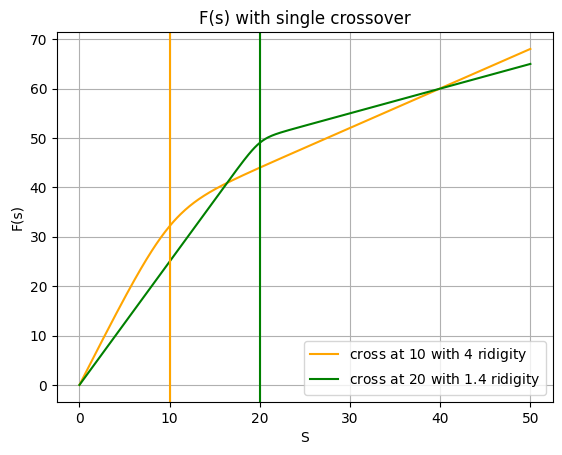

In [5]:
def plot_single_crossover():
    intercept=[0]
    c_11=[10]
    c_12=[20]
    slope_1=[2.2,0.8]
    slope_2=[1.5,0.5]
    r_11=[4]
    r_12=[1.4]
    all_values_1=c_11+slope_1+r_11
    all_values_2=c_12+slope_2+r_12
    x=np.linspace(0,50, num=500, endpoint=True)
    y_11=cross_fcn_sloped(x,intercept,*all_values_1,crossover_amount=len(c_11))
    y_12=cross_fcn_sloped(x,intercept, *all_values_2, crossover_amount=len(c_12))
    plt.Figure(figsize=(13,13))
    plt.plot(x,y_11, "orange", label=r"cross at $10$ with $4$ ridigity")
    plt.plot(x,y_12, "green", label=r"cross at $20$ with $1.4$ ridigity")
    plt.axvline(c_11,color="orange")
    plt.axvline(c_12, color="green")
    plt.grid()
    plt.ylabel("F(s)")
    plt.xlabel("S")
    plt.title('F(s) with single crossover')
    plt.legend()
    plt.show()
plot_single_crossover()

# Test with multiple crossovers

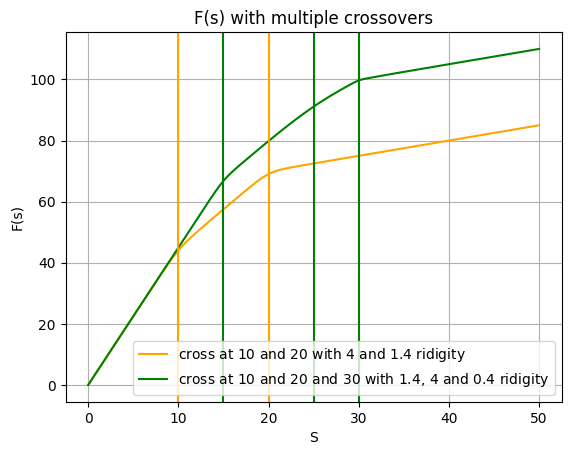

In [6]:
def plot_multiple_crossovers():
    x=np.linspace(0,50,num=500,endpoint=True)
    intercept=0
    c_11=[10,20]
    slope_1=[2.5,1.5,0.5]
    r_1=[1.4,1.4]
    all_values_1=c_11+slope_1+r_1
    y_11=cross_fcn_sloped(x,intercept,*all_values_1, crossover_amount=len(c_11))
    c_12=[15,25,30]
    slope_2=[2.5,1.5,1,0.5]
    r_2=[1,4,0.4]
    all_values_2=c_12+slope_2+r_2
    y_12=cross_fcn_sloped(x, intercept, *all_values_2, crossover_amount=len(c_12))
    plt.Figure(figsize=(10,10))
    plt.plot(x,y_11, "orange",label=r"cross at $10$ and $20$ with $4$ and $1.4$ ridigity")
    plt.plot(x, y_12,"green", label=r"cross at $10$ and $20$ and $30$ with $1.4$, $4$ and $0.4$ ridigity")
    for c in c_11:
        plt.axvline(c, color="orange")
    for c in c_12:
        plt.axvline(c, color="green")
    plt.grid()
    plt.ylabel("F(s)")
    plt.xlabel("S")
    plt.title('F(s) with multiple crossovers')
    plt.legend()
    plt.show()
plot_multiple_crossovers()

In [7]:
from dataclasses import dataclass
from functools import partial
from scipy.optimize import curve_fit
from scipy.stats import linregress

In [8]:
@dataclass
class var_estimation:
    value: float
    stderr: float


@dataclass
class ff_params:
    intercept: var_estimation
    cross: list[var_estimation]
    slopes: list[var_estimation]
    ridigity: list[var_estimation]

def get_number_parameter_by_number_crossovers(n: int) -> tuple[int, int]:
    """Returns the number of slopes and rigidity parameters for a given number of crossovers.

    Args:
        n (int): The number of crossovers in the fluctuation function.

    Returns:
        tuple[int, int]: A tuple containing the amount of slopes and the amount of rigidity (R) parameters.
    """
    slopes = n + 1
    R = n
    return slopes, R


def cross_fcn_sloped(x, y_0, *args, crossover_amount: int):
    """Computes the sloped crossover function for fluctuation characteristic approximation.

    This function serves as the base element for approximating fluctuation characteristics
    with multiple Hurst coefficients, incorporating crossover points.

    Args:
        x (np.ndarray): Points where the fluctuation function F(s) is calculated.
        y_0 (float): Y-intercept of the function.
        *args: Variable length argument list containing crossover values, slopes, and rigidity parameters.
        crossover_amount (int): Number of crossover points where the Hurst coefficient changes.

    Returns:
        np.ndarray: The computed function values at the given points.
    """
    crossovers = crossover_amount
    slopes_num, _ = get_number_parameter_by_number_crossovers(crossover_amount)
    C = args[:crossovers]
    slope = args[crossovers : crossovers + slopes_num]
    R = args[crossovers + slopes_num :]

    slope_fcn = np.zeros_like(x, dtype=float)
    fcn_bias = 0

    for index in range(slopes_num):
        if index == 0:
            left_c = -np.inf
            left_r = -np.inf

        else:
            left_c = C[index - 1]
            left_r = R[index - 1]

        if index == slopes_num - 1:
            right_c = np.inf
            right_r = np.inf
            # right_c = None
            # right_r = None
        else:
            right_c = C[index]
            right_r = R[index]
        slope_val = slope[index]

        b = slope_val * ff_base_appriximation(x, left_r, right_r, left_c, right_c)
        slope_fcn += b

        fcn_bias += slope_val * ff_base_appriximation(
            0, left_r, right_r, left_c, right_c
        )

    return y_0 + slope_fcn - fcn_bias


In [9]:
def analyse_cross_ff(
    hs: np.ndarray,
    S: np.ndarray,
    crossover_amount,
    max_ridigity: float = np.inf,
    min_ridigity: float = 0.2,
    min_slope_current: float = 0.05,
    max_slope_current: float = 50,
    ridigity_initial_parameter: float = 0.2,
    slope_current_initial_parameter: float = 0.5,
) -> tuple[ff_params, np.ndarray]:
    """Approximates the fluctuation function with multiple Hurst coefficients using non-linear least squares.

    This function fits a model with crossover points to the fluctuation function data using
    scipy.optimize.curve_fit for optimization. It returns the fitted parameters with their
    standard errors and the residuals of the fit.

    Args:
        hs (np.ndarray): The dependent data array, length M.
        S (np.ndarray): The independent variable array, shape (k, M)
        crossover_amount (int): Number of crossover points in the model.
        max_ridigity (float, optional): Maximum bound for rigidity parameters. Defaults to +np.inf.
        min_ridigity (float, optional): Minimum bound for rigidity parameters. Defaults to 1.
        min_slope_current (float, optional): Minimum bound for Hurst coefficients. Defaults to 0.
        max_slope_current (float, optional): Maximum bound for Hurst coefficients. Defaults to 5.
        ridigity_initial_parameter (float, optional): Initial guess for rigidity parameters. Defaults to 1.
        slope_current_initial_parameter (float, optional): Initial guess for Hurst coefficients. Defaults to 1.

    Returns:
        tuple[ff_params, np.ndarray]: A tuple containing the fitted parameters as an ff_params dataclass
        instance and the residuals as a numpy array.
    """

    # Initialization of optimization procedure
    s = np.repeat(S[:, np.newaxis], hs.shape[0], 1).T
    change_cross_value = partial(cross_fcn_sloped, crossover_amount=crossover_amount)
    s_count, r_count = get_number_parameter_by_number_crossovers(crossover_amount)
    min_ridigity = [
        min_ridigity,
    ] * r_count
    max_ridigity = [
        max_ridigity,
    ] * r_count
    min_slope_current = [
        min_slope_current,
    ] * s_count
    max_slope_current = [
        max_slope_current,
    ] * s_count
    min_crossover = [np.log10(S[0])] * crossover_amount
    max_crossover = [np.log10(S[-1])] * crossover_amount

    bounds_min = (
        [
            -np.inf,
        ]
        + min_crossover
        + min_slope_current
        + min_ridigity
    )
    bounds_max = (
        [
            +np.inf,
        ]
        + max_crossover
        + max_slope_current
        + max_ridigity
    )
    p0_crossover = [
        np.log10(S[0]) + (k + 1) * (np.log10(S[-1]) - np.log10(S[0])) / s_count
        for k in range(crossover_amount)
    ]

    p0 = (
        [
            0,
        ]
        + p0_crossover
        + [slope_current_initial_parameter] * s_count
        + [ridigity_initial_parameter] * r_count
    )

    # Perform an optimization
    popt, pcov, infodict, mesg, ier = curve_fit(
        change_cross_value,
        np.log10(s.flatten()),
        np.log10(hs.flatten()),
        p0=p0,
        bounds=(
            bounds_min,
            bounds_max,
        ),
        full_output=True,
        maxfev=10000,
        nan_policy="raise",
    )

    # Parse results into ff_params

    stderr = np.sqrt(np.diag(pcov))

    intercept_value = popt[0]
    intercept_err = stderr[0]
    cross_values = 10 ** popt[1 : crossover_amount + 1]
    slope_values = popt[crossover_amount + 1 : 2 * crossover_amount + 2]
    slope_errs = stderr[crossover_amount + 1 : 2 * crossover_amount + 2]
    ridigity_values = popt[2 * crossover_amount + 2 :]
    ridigity_err = stderr[2 * crossover_amount + 2 :]
    cross_err = 10 ** stderr[1 : crossover_amount + 1]

    return (
        ff_params(
            intercept=var_estimation(value=intercept_value, stderr=intercept_err),
            cross=[
                var_estimation(value=v, stderr=e)
                for v, e in zip(cross_values, cross_err)
            ],
            slopes=[
                var_estimation(value=v, stderr=e)
                for v, e in zip(slope_values, slope_errs)
            ],
            ridigity=[
                var_estimation(value=v, stderr=e)
                for v, e in zip(ridigity_values, ridigity_err)
            ],
        ),
        10 ** change_cross_value(np.log10(s), 0, *popt) - hs,
    )


def analyse_zero_cross_ff(
    hs: np.ndarray,
    S: np.ndarray,
) -> tuple[ff_params, np.ndarray]:
    """Approximates the fluctuation function with one Hurst coefficient using linear least squares regression.

    This function fits a model with zero crossover points to the fluctuation function data. It returns the fitted parameters with their
    standard errors and the residuals of the fit.

    Args:
        hs (np.ndarray): The dependent data array, length M.
        S (np.ndarray): The independent variable array, shape (k, M).
    Returns:
        tuple[ff_params, np.ndarray]: A tuple containing the fitted parameters as an ff_params dataclass
        instance and the residuals as a numpy array.
    """

    s = np.repeat(S[np.newaxis, :], hs.shape[0], axis=0)
    log_s = np.log10(s)
    log_hs = np.log10(hs)
    x = log_s.flatten()
    y = log_hs.flatten()
    result = linregress(x, y)

    fit_model = 10 ** (result.slope * np.log10(s) + result.intercept)
    residuals = fit_model - hs
    return (
        ff_params(
            intercept=var_estimation(
                value=result.intercept, stderr=result.intercept_stderr
            ),
            cross=[],
            slopes=[var_estimation(value=result.slope, stderr=result.stderr)],
            ridigity=[],
        ),
        residuals,
    )


In [10]:
def plot_ff(
    hs: np.ndarray,
    S: np.ndarray,
    ff_parameter: ff_params,
    residuals=None,
    ax=None,
    title=None,
):
    """Plots the fluctuation function with fitted parameters and crossover points and zero crossover points.

    This function visualizes the fluctuation function data along with the fitted model,
    including error bars if residuals are provided, and marks the crossover points.

    Args:
        hs (np.ndarray): The dependent data array, length M.
        S (np.ndarray): The independent variable array, shape (k, M)
        ff_parameter (ff_params): Fitted parameters from the fluctuation function analysis.
        residuals (np.ndarray, optional): Residuals for plotting error bars. Defaults to None.
        ax (matplotlib.axes.Axes, optional): Matplotlib axis to plot on. If None, creates a new figure. Defaults to None.

    Returns:
        matplotlib.axes.Axes: The matplotlib axis containing the plot.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(30, 30))
    slopes = [slp.value for slp in ff_parameter.slopes]
    crossovers = [cross.value for cross in ff_parameter.cross]
    R = [r.value for r in ff_parameter.ridigity]
    intercept = (ff_parameter.intercept.value,)
    if len(crossovers) == 0:
        hurst = ff_parameter.slopes[0].value
        b = ff_parameter.intercept.value
        hs_array = np.asarray(hs)
        fit_func = 10 ** (hurst * np.log10(S) + b)
        if hs_array.ndim == 1:
            ax.plot(S, hs_array, ".", label=rf"$H_0(S) \sim {hurst:.2f} \cdot S$")
        else:
            S_rep = np.tile(S, (hs_array.shape[0], 1))
            ax.plot(
                S_rep.ravel(),
                hs_array.ravel(),
                ".",
                label=rf"$H_0(S) \sim {hurst:.2f} \cdot S$",
            )
    else:
        all_values = [np.log10(c) for c in crossovers] + slopes + R
        fit_func = 10 ** cross_fcn_sloped(
            np.log10(S),
            intercept,
            *all_values,
            crossover_amount=len(crossovers),
        )
        S_new = np.repeat(S[:, np.newaxis], hs.shape[0], 1).T
        array_for_limits = [-np.inf] + list(crossovers) + [+np.inf]
        for index_value, plot_value in enumerate(slopes):
            current_lim = array_for_limits[index_value]
            next_lim = array_for_limits[index_value + 1]
            mask = (S_new >=current_lim) & (S_new <= next_lim)
            ax.plot(
                S_new[mask],
                hs[mask],
                ".",
                label=rf"$H_0(S) \sim {slopes[index_value]:.2f} \cdot S$",
            )

        for c in ff_parameter.cross:
            ax.axvline(
                c.value, color="k", linestyle="--", label=f"Cross at $S={c.value:.2f}$"
            )
    if residuals is not None:
        ax.errorbar(
            S,
            fit_func,
            fmt="g--",
            capsize=7,
            yerr=2 * np.std(residuals, axis=0),
            label=r"$F(S) \pm 2\sigma$",
        )
    else:
        ax.plot(S, fit_func, label=r"F(S)")
    if title:
        ax.set_title(title)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(which="both")
    ax.legend()

    return ax


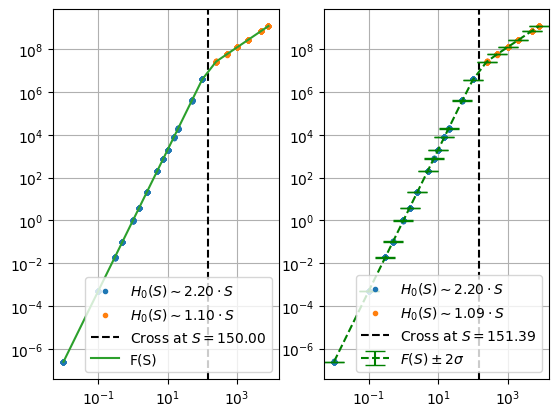

In [11]:
tst_s = np.array(
    [0.01, 0.1, 0.3, 0.5, 1, 1.5, 2.5, 5, 7.5, 10, 15, 20, 50, 100, 250, 500, 1000,2000,5000,8000]
)

y_0 = 0
cross = [150]
cross_log = list(np.log10(cross))
slope = [2.2, 1.1]
r = [0.1]
all_values = cross_log + slope + r
tst_h_multiple = 10 ** cross_fcn_sloped(
    np.log10(tst_s), y_0, *all_values, crossover_amount=len(cross)
)


cross_error = [0]
slope_error = [0, 0]
r_error = [0]

cross_list = [
    var_estimation(value=10**v, stderr=10**e) for v, e in zip(cross_log, cross_error)
]
slopes_list = [var_estimation(value=v, stderr=e) for v, e in zip(slope, slope_error)]
ridigity_list = [var_estimation(value=v, stderr=e) for v, e in zip(r, r_error)]

ff_params_new = ff_params(
    intercept=var_estimation(value=y_0, stderr=0),
    cross=cross_list,
    slopes=slopes_list,
    ridigity=ridigity_list,
)
tst_hr_multiple_approx = 1 + np.random.normal(0, 0.01, (20, len(tst_h_multiple)))
tst_h_multiple = tst_hr_multiple_approx * tst_h_multiple


fig, axs = plt.subplots(1, 2)
plot_ff(tst_h_multiple, tst_s, ff_params_new, ax=axs[0])

ff_parameters_approx, residuals_approx = analyse_cross_ff(
    tst_h_multiple, tst_s, crossover_amount=len(cross)
)


plot_ff(
    tst_h_multiple,
    tst_s,
    ff_parameter=ff_parameters_approx,
    residuals=residuals_approx,
    ax=axs[1],
)

plt.show()


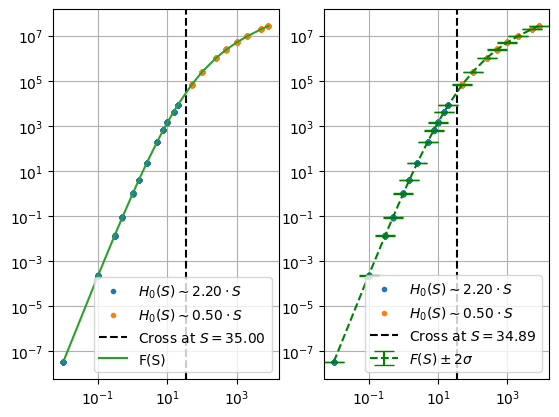

In [12]:
tst_s = np.array(
    [0.01, 0.1, 0.3, 0.5, 1, 1.5, 2.5, 5, 7.5, 10, 15, 20, 50, 100, 250, 500, 1000,2000,5000,8000]
)

y_0 = 0
cross = [35]
cross_log = list(np.log10(cross))
slope = [2.2, 0.5]
r = [1.6]
all_values = cross_log + slope + r
tst_h_multiple = 10 ** cross_fcn_sloped(
    np.log10(tst_s), y_0, *all_values, crossover_amount=len(cross)
)


cross_error = [0]
slope_error = [0, 0]
r_error = [0]

cross_list = [
    var_estimation(value=10**v, stderr=10**e) for v, e in zip(cross_log, cross_error)
]
slopes_list = [var_estimation(value=v, stderr=e) for v, e in zip(slope, slope_error)]
ridigity_list = [var_estimation(value=v, stderr=e) for v, e in zip(r, r_error)]

ff_params_new = ff_params(
    intercept=var_estimation(value=y_0, stderr=0),
    cross=cross_list,
    slopes=slopes_list,
    ridigity=ridigity_list,
)
tst_hr_multiple_approx = 1 + np.random.normal(0, 0.01, (20, len(tst_h_multiple)))
tst_h_multiple = tst_hr_multiple_approx * tst_h_multiple


fig, axs = plt.subplots(1, 2)
plot_ff(tst_h_multiple, tst_s, ff_params_new, ax=axs[0])

ff_parameters_approx, residuals_approx = analyse_cross_ff(
    tst_h_multiple, tst_s, crossover_amount=len(cross)
)


plot_ff(
    tst_h_multiple,
    tst_s,
    ff_parameter=ff_parameters_approx,
    residuals=residuals_approx,
    ax=axs[1],
)

plt.show()


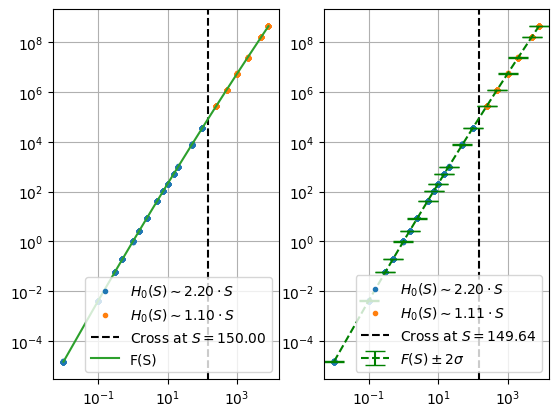

In [90]:
tst_s = np.array(
    [0.01, 0.1, 0.3, 0.5, 1, 1.5, 2.5, 5, 7.5, 10, 15, 20, 50, 100, 250, 500, 1000,2000,5000,8000]
)

y_0 = 0
cross = [150]
cross_log = list(np.log10(cross))
slope = [2.2, 1.1]
r = [16]
all_values = cross_log + slope + r
tst_h_multiple = 10 ** cross_fcn_sloped(
    np.log10(tst_s), y_0, *all_values, crossover_amount=len(cross)
)


cross_error = [0]
slope_error = [0, 0]
r_error = [0]

cross_list = [
    var_estimation(value=10**v, stderr=10**e) for v, e in zip(cross_log, cross_error)
]
slopes_list = [var_estimation(value=v, stderr=e) for v, e in zip(slope, slope_error)]
ridigity_list = [var_estimation(value=v, stderr=e) for v, e in zip(r, r_error)]

ff_params_new = ff_params(
    intercept=var_estimation(value=y_0, stderr=0),
    cross=cross_list,
    slopes=slopes_list,
    ridigity=ridigity_list,
)
tst_hr_multiple_approx = 1 + np.random.normal(0, 0.01, (20, len(tst_h_multiple)))
tst_h_multiple = tst_hr_multiple_approx * tst_h_multiple


fig, axs = plt.subplots(1, 2)
plot_ff(tst_h_multiple, tst_s, ff_params_new, ax=axs[0])

ff_parameters_approx, residuals_approx = analyse_cross_ff(
    tst_h_multiple, tst_s, crossover_amount=len(cross)
)


plot_ff(
    tst_h_multiple,
    tst_s,
    ff_parameter=ff_parameters_approx,
    residuals=residuals_approx,
    ax=axs[1],
)

plt.show()
